## 1. Importar Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Carga de Datos

Instrucciones: 
- Descarga el dataset de Kaggle: [Sephora Products and Skincare Reviews](https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews)
- Coloca los archivos CSV en la carpeta `data/`
- Archivos esperados: `product_info.csv` y `reviews.csv`

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("nadyinky/sephora-products-and-skincare-reviews")

print("Dataset descargado desde Kaggle")
print(f"Path to dataset files: {path}")

print(f"\nArchivos disponibles:")
for file in os.listdir(path):
    file_path = os.path.join(path, file)
    size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"   - {file} ({size_mb:.2f} MB)")

Dataset descargado desde Kaggle
Path to dataset files: C:\Users\pared\.cache\kagglehub\datasets\nadyinky\sephora-products-and-skincare-reviews\versions\2

Archivos disponibles:
   - product_info.csv (7.55 MB)
   - reviews_0-250.csv (269.18 MB)
   - reviews_1250-end.csv (23.07 MB)
   - reviews_250-500.csv (95.65 MB)
   - reviews_500-750.csv (53.70 MB)
   - reviews_750-1250.csv (55.29 MB)


In [3]:
product_file = os.path.join(path, 'product_info.csv')
df_products = pd.read_csv(product_file)

print(f"Dataset de Productos cargado")
print(f"   - Shape: {df_products.shape}")
print(f"   - Tamaño en memoria: {df_products.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

df_products.head()

Dataset de Productos cargado
   - Shape: (8494, 27)
   - Tamaño en memoria: 12.95 MB


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.636,11.000,NaN,NaN,NaN,NaN,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.000,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.154,13.000,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.000,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.000,30.000
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.250,16.000,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.000,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.000,30.000
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.476,21.000,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.000,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.000,30.000
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.231,13.000,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.000,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.000,30.000


In [4]:
reviews_file = os.path.join(path, 'reviews_0-250.csv')
df_reviews = pd.read_csv(reviews_file)

print(f"Dataset de Reviews cargado")
print(f"   - Shape: {df_reviews.shape}")
print(f"   - Tamaño en memoria: {df_reviews.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

df_reviews.head()

Dataset de Reviews cargado
   - Shape: (602130, 19)
   - Tamaño en memoria: 719.39 MB
   - Tamaño en memoria: 719.39 MB


,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.000,1.000,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.000
1,1,31423088263,1,0.000,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.000
2,2,5061282401,5,1.000,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.000
3,3,6083038851,5,1.000,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.000
4,4,47056667835,5,1.000,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.000


## 3. Información General del Dataset

In [5]:
# Información de productos
print("="*80)
print("INFORMACIÓN DEL DATASET DE PRODUCTOS")
print("="*80)
df_products.info()

INFORMACIÓN DEL DATASET DE PRODUCTOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   object 
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   object 
 8   variation_type      7050 non-null   object 
 9   variation_value     6896 non-null   object 
 10  variation_desc      1250 non-null   object 
 11  ingredients         7549 non-null   object 
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition   

In [6]:
print("\nESTADISTICAS DESCRIPTIVAS - PRODUCTOS\n")
df_products.describe()


ESTADISTICAS DESCRIPTIVAS - PRODUCTOS



,brand_id,loves_count,rating,reviews,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,child_count,child_max_price,child_min_price
count,8494.000,8494.000,8216.000,8216.000,8494.000,451.000,270.000,8494.000,8494.000,8494.000,8494.000,8494.000,8494.000,2754.000,2754.000
mean,5422.441,29179.566,4.195,448.546,51.656,91.169,20.208,0.070,0.072,0.219,0.074,0.279,1.632,53.792,39.666
std,1709.596,66092.123,0.517,1101.983,53.669,79.196,24.327,0.256,0.258,0.414,0.261,0.449,5.379,58.766,38.686
min,1063.000,0.000,1.000,1.000,3.000,0.000,1.750,0.000,0.000,0.000,0.000,0.000,0.000,3.000,3.000
25%,5333.000,3758.000,3.982,26.000,25.000,45.000,8.000,0.000,0.000,0.000,0.000,0.000,0.000,22.000,19.000
50%,6157.500,9880.000,4.289,122.000,35.000,67.000,14.000,0.000,0.000,0.000,0.000,0.000,0.000,32.000,28.000
75%,6328.000,26841.250,4.531,418.000,58.000,108.500,25.000,0.000,0.000,0.000,0.000,1.000,1.000,59.000,42.000
max,8020.000,1401068.000,5.000,21281.000,1900.000,617.000,320.000,1.000,1.000,1.000,1.000,1.000,105.000,570.000,400.000


In [7]:
# Información de reviews
print("="*80)
print("INFORMACIÓN DEL DATASET DE REVIEWS")
print("="*80)
df_reviews.info()

INFORMACIÓN DEL DATASET DE REVIEWS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602130 entries, 0 to 602129
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                602130 non-null  int64  
 1   author_id                 602130 non-null  object 
 2   rating                    602130 non-null  int64  
 3   is_recommended            484644 non-null  float64
 4   helpfulness               270298 non-null  float64
 5   total_feedback_count      602130 non-null  int64  
 6   total_neg_feedback_count  602130 non-null  int64  
 7   total_pos_feedback_count  602130 non-null  int64  
 8   submission_time           602130 non-null  object 
 9   review_text               601131 non-null  object 
 10  review_title              435119 non-null  object 
 11  skin_tone                 496074 non-null  object 
 12  eye_color                 463642 non-null  object 
 13  skin_type

In [8]:
print("\nESTADISTICAS DESCRIPTIVAS - REVIEWS\n")
df_reviews.describe()


ESTADISTICAS DESCRIPTIVAS - REVIEWS



,Unnamed: 0,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,price_usd
count,602130.000,602130.000,484644.000,270298.000,602130.000,602130.000,602130.000,602130.000
mean,301064.500,4.312,0.838,0.770,3.661,0.765,2.895,45.724
std,173820.103,1.144,0.369,0.319,25.848,4.968,22.629,35.744
min,0.000,1.000,0.000,0.000,0.000,0.000,0.000,3.000
25%,150532.250,4.000,1.000,0.667,0.000,0.000,0.000,23.500
50%,301064.500,5.000,1.000,0.944,0.000,0.000,0.000,38.000
75%,451596.750,5.000,1.000,1.000,3.000,0.000,2.000,60.000
max,602129.000,5.000,1.000,1.000,5464.000,573.000,5050.000,380.000


## 4. Análisis de Valores Nulos


ANALISIS DE VALORES NULOS - PRODUCTOS

            Column  Null_Count  Null_Percentage Data_Type
    sale_price_usd        8224           96.821   float64
   value_price_usd        8043           94.690   float64
    variation_desc        7244           85.284    object
   child_max_price        5740           67.577   float64
   child_min_price        5740           67.577   float64
        highlights        2207           25.983    object
              size        1631           19.202    object
   variation_value        1598           18.813    object
    variation_type        1444           17.000    object
 tertiary_category         990           11.655    object
       ingredients         945           11.126    object
           reviews         278            3.273   float64
            rating         278            3.273   float64
secondary_category           8            0.094    object


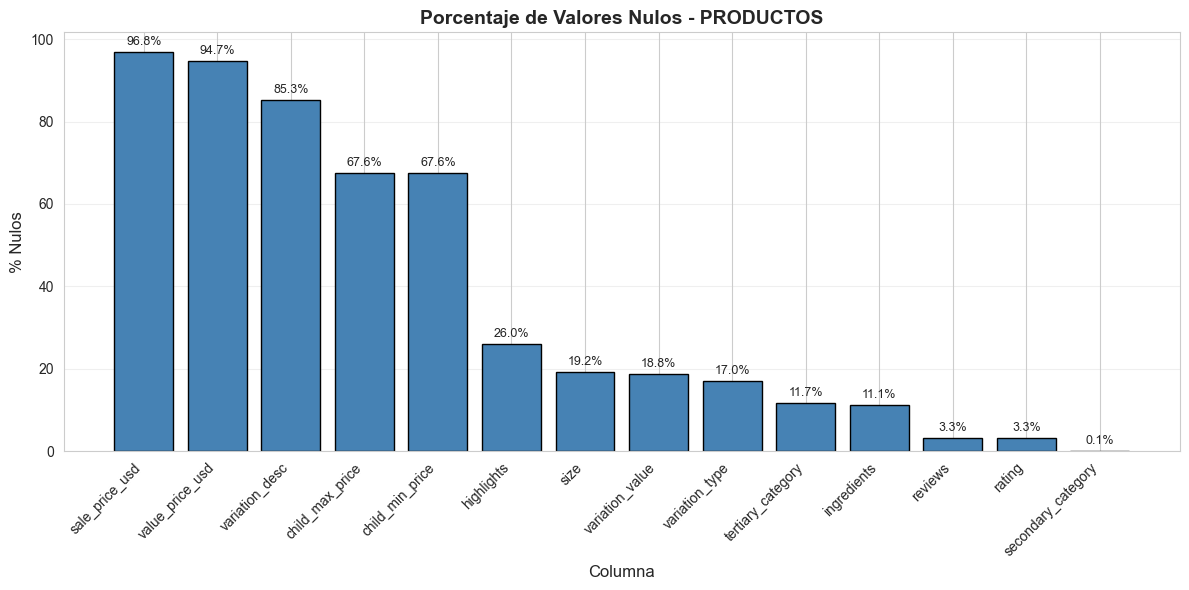

In [9]:
def analyze_nulls(df, dataset_name):
    print(f"\n{'='*80}")
    print(f"ANALISIS DE VALORES NULOS - {dataset_name}")
    print(f"{'='*80}\n")
    
    null_counts = df.isnull().sum()
    null_percentages = (null_counts / len(df)) * 100
    
    null_df = pd.DataFrame({
        'Column': null_counts.index,
        'Null_Count': null_counts.values,
        'Null_Percentage': null_percentages.values,
        'Data_Type': df.dtypes.values
    })
    
    null_df = null_df[null_df['Null_Count'] > 0].sort_values('Null_Percentage', ascending=False)
    
    if len(null_df) > 0:
        print(null_df.to_string(index=False))
        
        plt.figure(figsize=(12, 6))
        plt.bar(null_df['Column'], null_df['Null_Percentage'], color='steelblue', edgecolor='black')
        plt.xlabel('Columna', fontsize=12)
        plt.ylabel('% Nulos', fontsize=12)
        plt.title(f'Porcentaje de Valores Nulos - {dataset_name}', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        
        for i, (col, pct) in enumerate(zip(null_df['Column'], null_df['Null_Percentage'])):
            plt.text(i, pct + 1, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No hay valores nulos en el dataset")
    
    return null_df

nulls_products = analyze_nulls(df_products, "PRODUCTOS")


ANALISIS DE VALORES NULOS - REVIEWS

        Column  Null_Count  Null_Percentage Data_Type
   helpfulness      331832           55.110   float64
  review_title      167011           27.737    object
    hair_color      141081           23.430    object
     eye_color      138488           23.000    object
is_recommended      117486           19.512   float64
     skin_tone      106056           17.613    object
     skin_type       74683           12.403    object
   review_text         999            0.166    object
        Column  Null_Count  Null_Percentage Data_Type
   helpfulness      331832           55.110   float64
  review_title      167011           27.737    object
    hair_color      141081           23.430    object
     eye_color      138488           23.000    object
is_recommended      117486           19.512   float64
     skin_tone      106056           17.613    object
     skin_type       74683           12.403    object
   review_text         999            0.166 

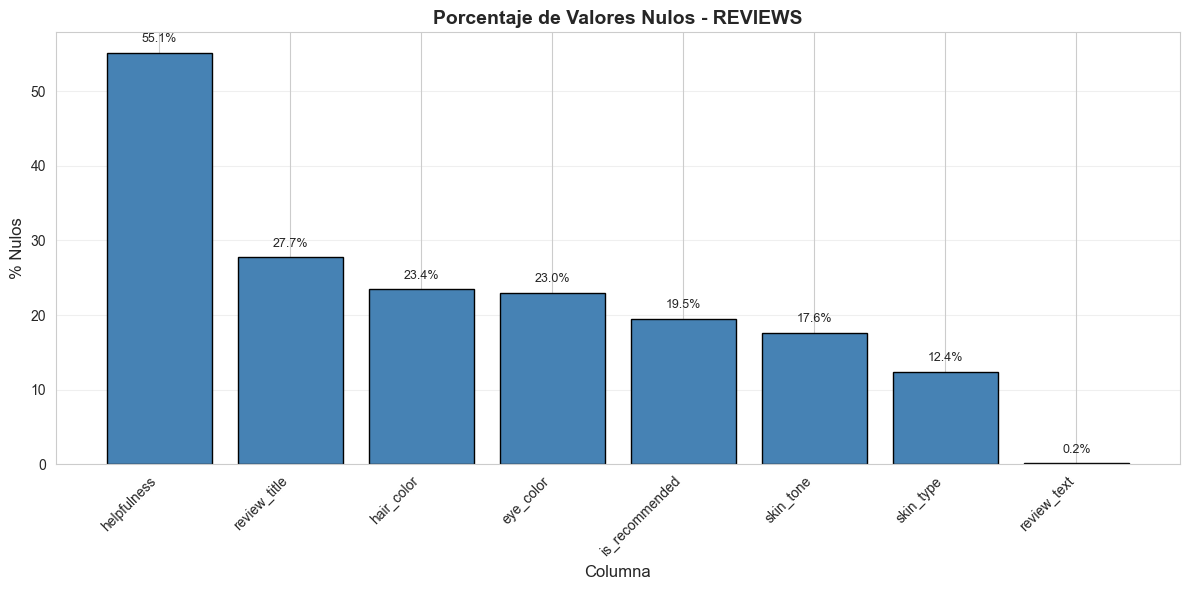

In [10]:
nulls_reviews = analyze_nulls(df_reviews, "REVIEWS")

## 5. Análisis de Distribuciones - Variables Numéricas

In [11]:
numeric_cols = ['loves_count', 'rating', 'reviews', 'price_usd', 'value_price_usd', 
                'sale_price_usd', 'child_count', 'child_max_price', 'child_min_price']

numeric_cols = [col for col in numeric_cols if col in df_products.columns]

print(f"Variables numéricas a analizar: {len(numeric_cols)}")
print(numeric_cols)

Variables numéricas a analizar: 9
['loves_count', 'rating', 'reviews', 'price_usd', 'value_price_usd', 'sale_price_usd', 'child_count', 'child_max_price', 'child_min_price']


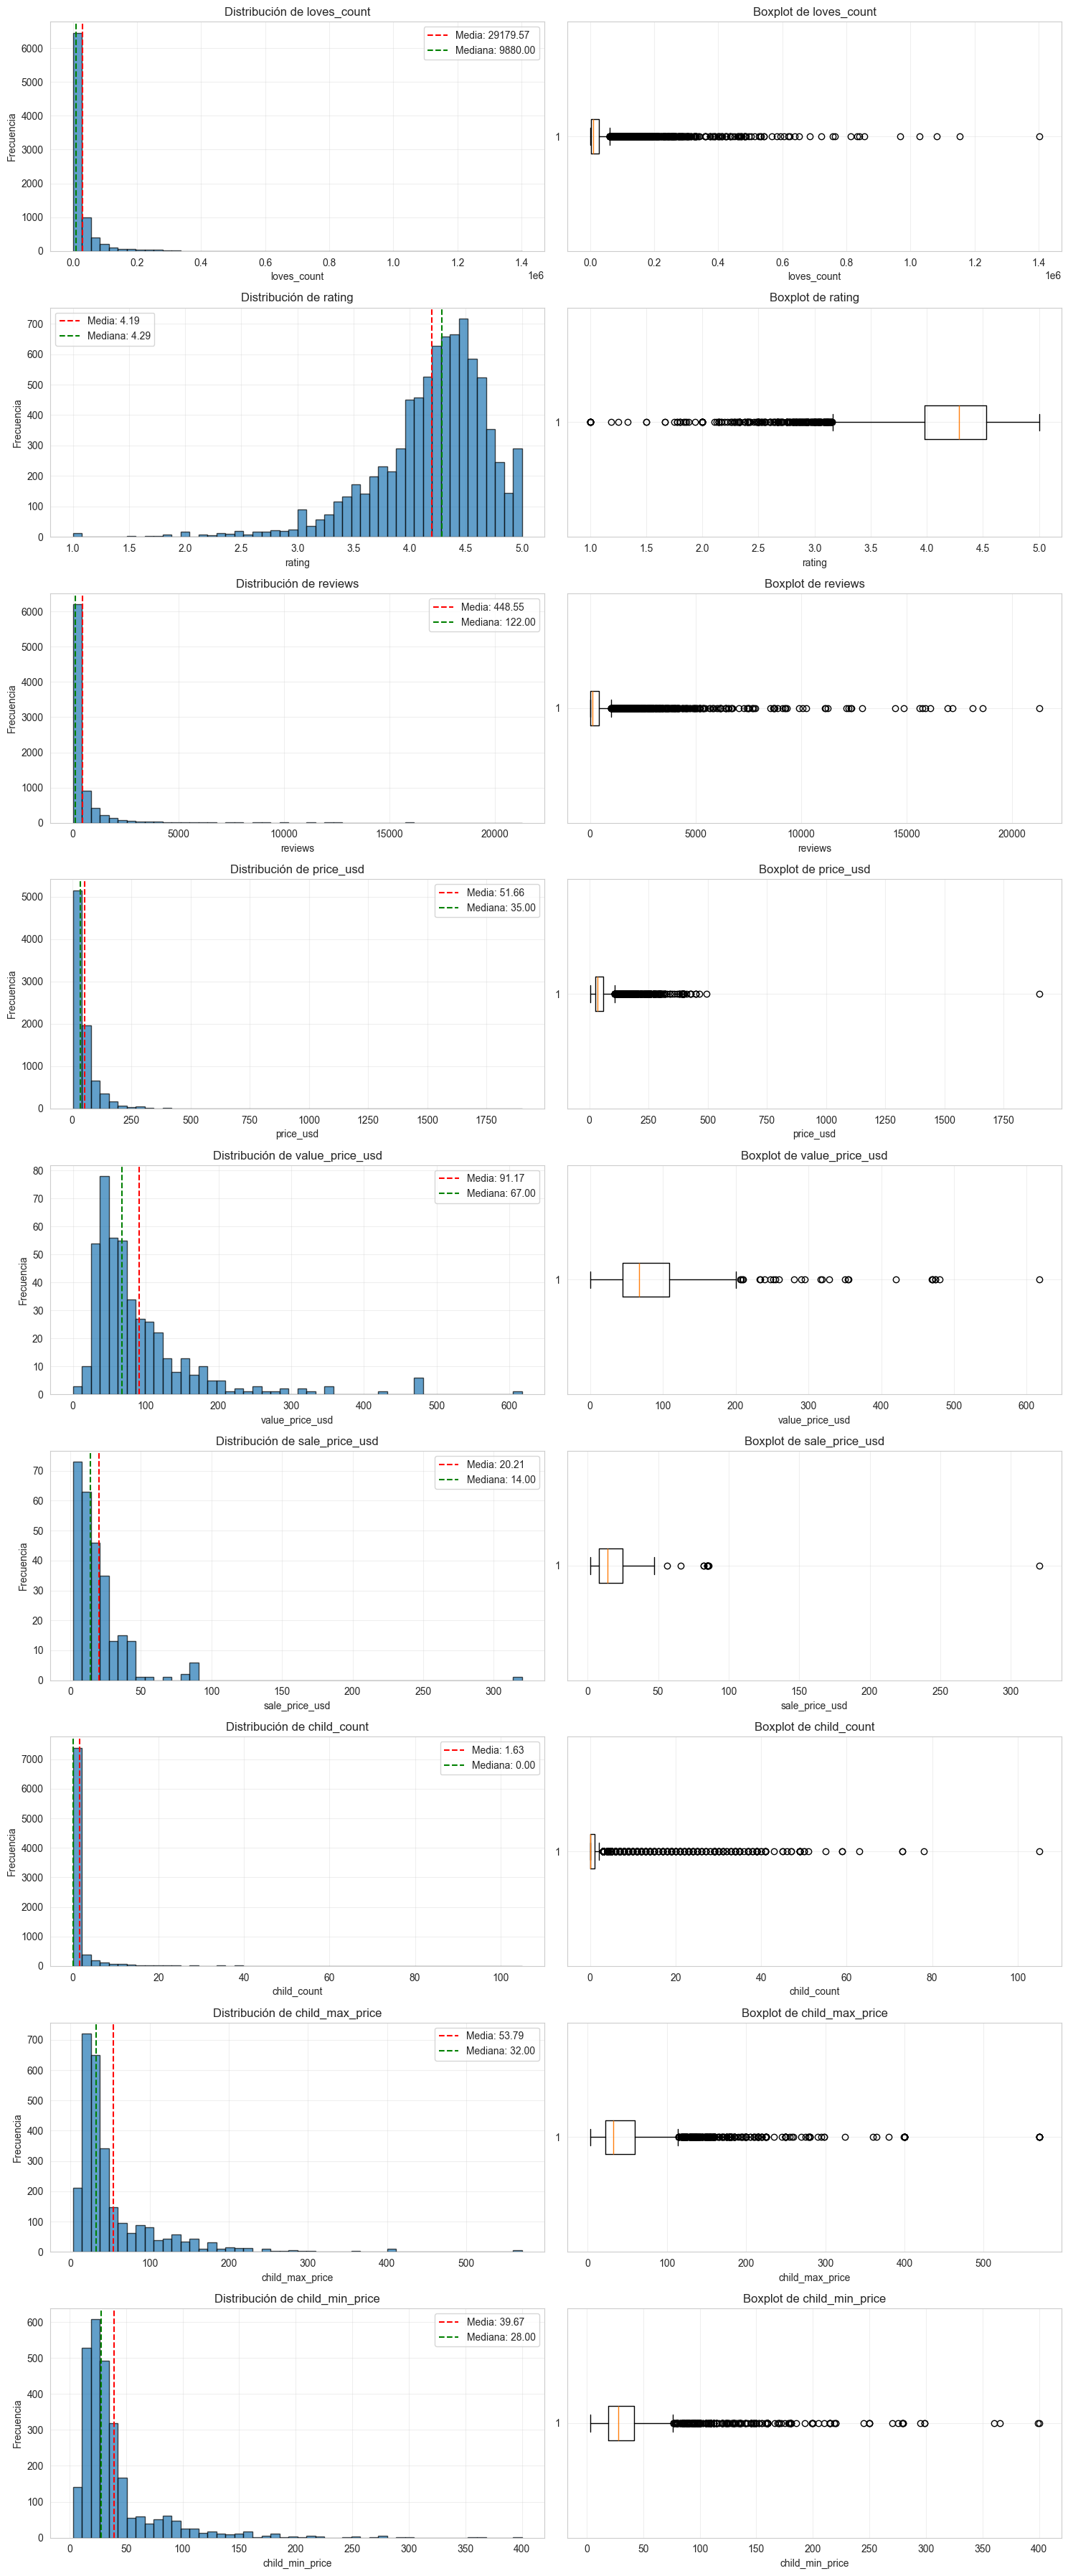

Distribuciones visualizadas


In [12]:
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(15, len(numeric_cols)*4))

for idx, col in enumerate(numeric_cols):
    axes[idx, 0].hist(df_products[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'Distribución de {col}')
    axes[idx, 0].set_xlabel(col)
    axes[idx, 0].set_ylabel('Frecuencia')
    axes[idx, 0].grid(True, alpha=0.3)
    
    mean_val = df_products[col].mean()
    median_val = df_products[col].median()
    axes[idx, 0].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    axes[idx, 0].axvline(median_val, color='green', linestyle='--', label=f'Mediana: {median_val:.2f}')
    axes[idx, 0].legend()
    
    axes[idx, 1].boxplot(df_products[col].dropna(), vert=False)
    axes[idx, 1].set_title(f'Boxplot de {col}')
    axes[idx, 1].set_xlabel(col)
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Distribuciones visualizadas")

In [13]:
print("\nANALISIS DE OUTLIERS (Método IQR)\n")
print(f"{'Variable':<20} {'Q1':<10} {'Q3':<10} {'IQR':<10} {'Outliers':<10} {'% Outliers':<12}")
print("="*82)

outlier_summary = []

for col in numeric_cols:
    Q1 = df_products[col].quantile(0.25)
    Q3 = df_products[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_products[(df_products[col] < lower_bound) | (df_products[col] > upper_bound)][col]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df_products)) * 100
    
    print(f"{col:<20} {Q1:<10.2f} {Q3:<10.2f} {IQR:<10.2f} {outlier_count:<10} {outlier_pct:<12.2f}%")
    
    outlier_summary.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Outliers': outlier_count,
        'Outlier_Pct': outlier_pct
    })

outlier_df = pd.DataFrame(outlier_summary)


ANALISIS DE OUTLIERS (Método IQR)

Variable             Q1         Q3         IQR        Outliers   % Outliers  
loves_count          3758.00    26841.25   23083.25   951        11.20       %
rating               3.98       4.53       0.55       339        3.99        %
reviews              26.00      418.00     392.00     913        10.75       %
price_usd            25.00      58.00      33.00      845        9.95        %
value_price_usd      45.00      108.50     63.50      28         0.33        %
sale_price_usd       8.00       25.00      17.00      11         0.13        %
child_count          0.00       1.00       1.00       1101       12.96       %
child_max_price      22.00      59.00      37.00      322        3.79        %
child_min_price      19.00      42.00      23.00      323        3.80        %


## 6. Análisis de Variables Categóricas

In [14]:
categorical_cols = ['brand_name', 'primary_category', 'secondary_category', 'tertiary_category',
                    'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive']

categorical_cols = [col for col in categorical_cols if col in df_products.columns]

print(f"Variables categóricas a analizar: {len(categorical_cols)}")
print(categorical_cols)

Variables categóricas a analizar: 9
['brand_name', 'primary_category', 'secondary_category', 'tertiary_category', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive']


In [15]:
print("\nCARDINALIDAD DE VARIABLES CATEGORICAS\n")
print(f"{'Variable':<25} {'Valores Únicos':<20} {'Top Valor':<30} {'Frecuencia Top'}")
print("="*100)

for col in categorical_cols:
    unique_count = df_products[col].nunique()
    top_value = df_products[col].value_counts().index[0] if len(df_products[col].value_counts()) > 0 else 'N/A'
    top_freq = df_products[col].value_counts().values[0] if len(df_products[col].value_counts()) > 0 else 0
    
    top_value_str = str(top_value)[:27] + '...' if len(str(top_value)) > 30 else str(top_value)
    
    print(f"{col:<25} {unique_count:<20} {top_value_str:<30} {top_freq}")


CARDINALIDAD DE VARIABLES CATEGORICAS

Variable                  Valores Únicos       Top Valor                      Frecuencia Top
brand_name                304                  SEPHORA COLLECTION             352
primary_category          9                    Skincare                       2420
secondary_category        41                   Women                          875
tertiary_category         118                  Perfume                        568
limited_edition           2                    0                              7897
new                       2                    0                              7885
online_only               2                    0                              6633
out_of_stock              2                    0                              7868
sephora_exclusive         2                    0                              6121


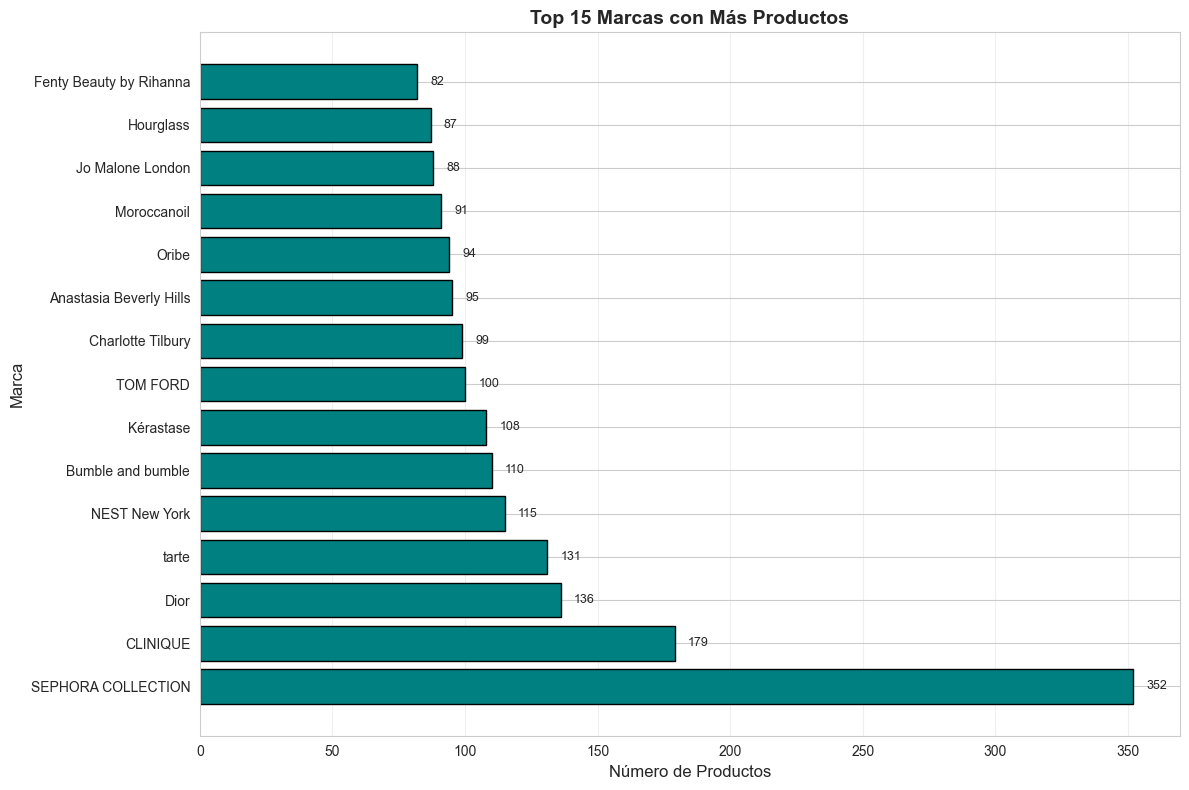

In [16]:
# Top 15 marcas más populares
top_brands = df_products['brand_name'].value_counts().head(15)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_brands)), top_brands.values, color='teal', edgecolor='black')
plt.yticks(range(len(top_brands)), top_brands.index)
plt.xlabel('Número de Productos', fontsize=12)
plt.ylabel('Marca', fontsize=12)
plt.title('Top 15 Marcas con Más Productos', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Agregar valores
for i, val in enumerate(top_brands.values):
    plt.text(val + 5, i, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

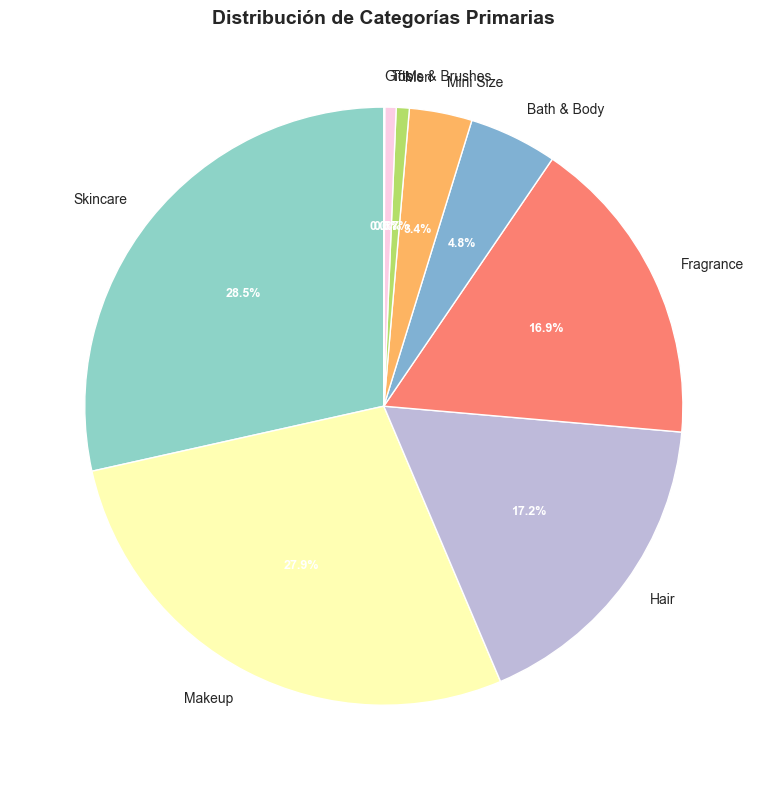

In [17]:
# Distribución de categorías primarias
if 'primary_category' in df_products.columns:
    category_counts = df_products['primary_category'].value_counts()
    
    plt.figure(figsize=(10, 8))
    colors = plt.cm.Set3(range(len(category_counts)))
    wedges, texts, autotexts = plt.pie(category_counts.values, 
                                         labels=category_counts.index, 
                                         autopct='%1.1f%%',
                                         startangle=90,
                                         colors=colors)
    
    # Mejorar formato de texto
    for text in texts:
        text.set_fontsize(10)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(9)
    
    plt.title('Distribución de Categorías Primarias', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

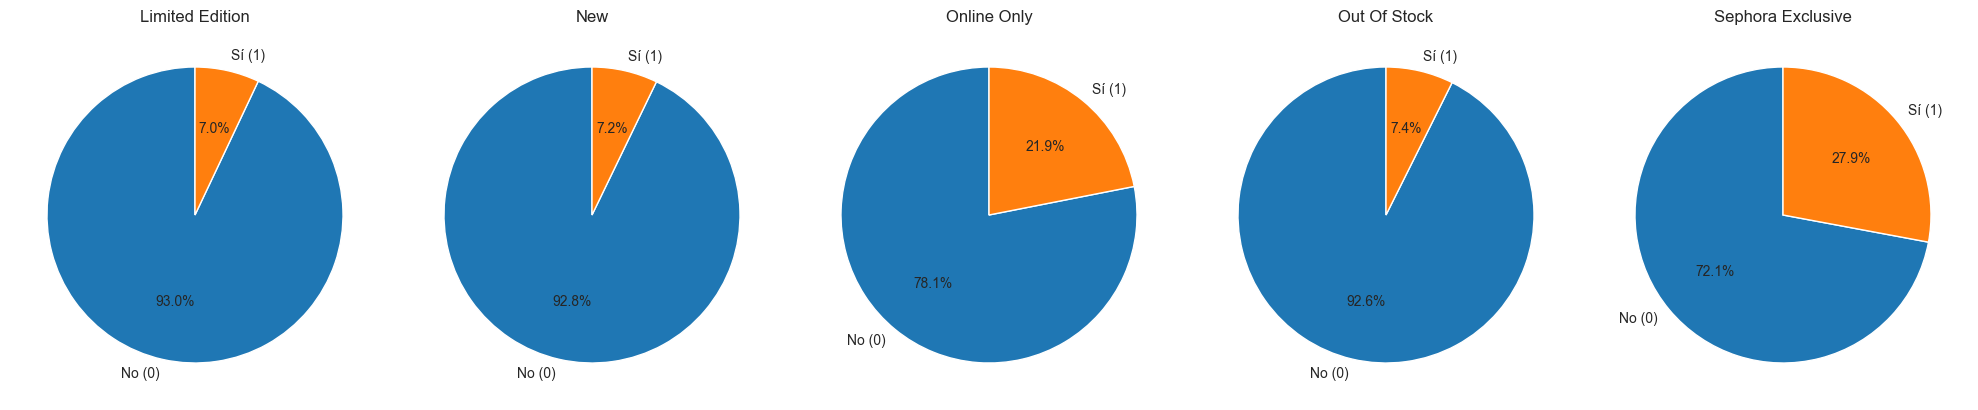

In [18]:
# Variables binarias
binary_cols = ['limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive']
binary_cols = [col for col in binary_cols if col in df_products.columns]

if len(binary_cols) > 0:
    fig, axes = plt.subplots(1, len(binary_cols), figsize=(4*len(binary_cols), 4))
    
    if len(binary_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(binary_cols):
        counts = df_products[col].value_counts()
        axes[idx].pie(counts.values, labels=['No (0)', 'Sí (1)'], autopct='%1.1f%%', startangle=90)
        axes[idx].set_title(col.replace('_', ' ').title())
    
    plt.tight_layout()
    plt.show()

## 7. Análisis de Correlaciones

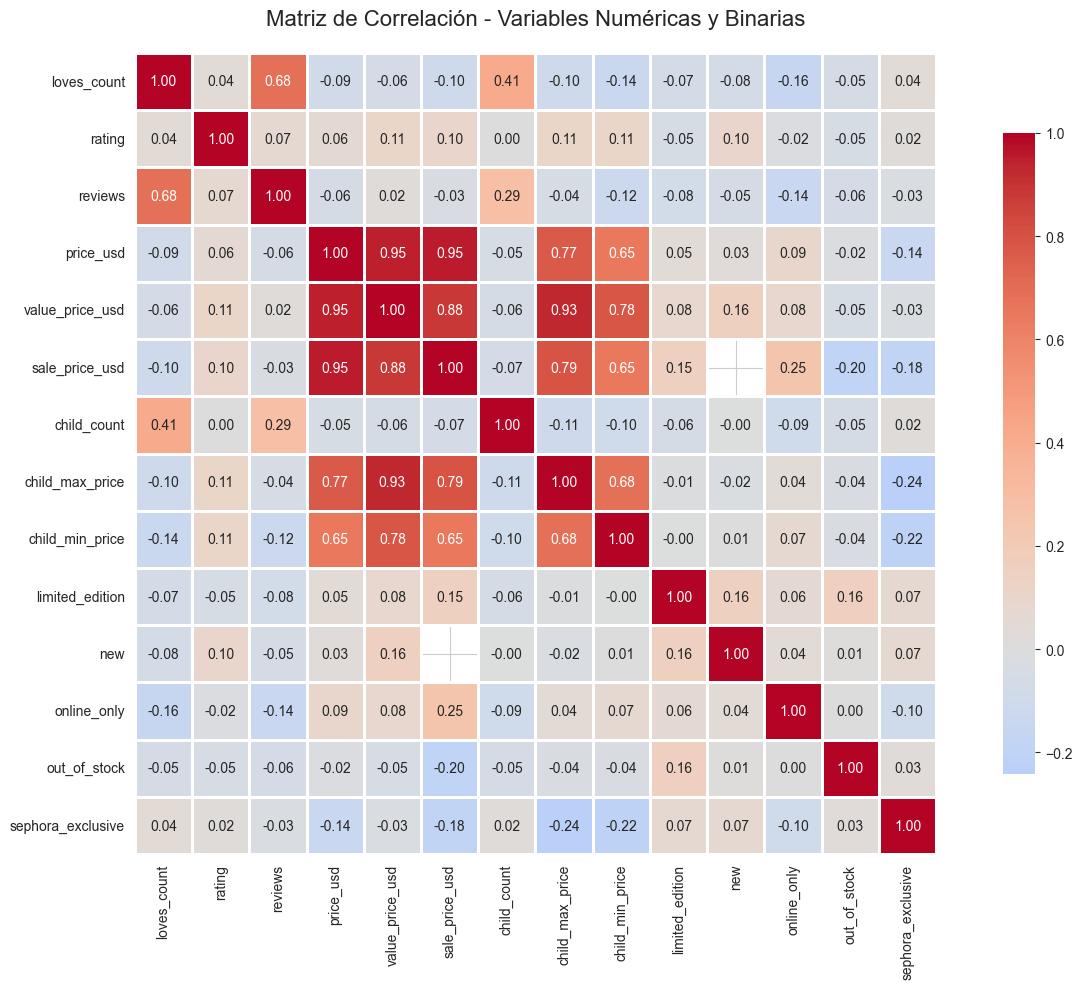

In [19]:
# Matriz de correlación
correlation_cols = numeric_cols + binary_cols
correlation_cols = [col for col in correlation_cols if col in df_products.columns]

corr_matrix = df_products[correlation_cols].corr()

# Visualización con heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables Numéricas y Binarias', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [20]:
print("\nTOP 10 CORRELACIONES MAS FUERTES\n")

corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append({
            'Variable_1': corr_matrix.columns[i],
            'Variable_2': corr_matrix.columns[j],
            'Correlation': corr_matrix.iloc[i, j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs)
corr_pairs_df['Abs_Correlation'] = corr_pairs_df['Correlation'].abs()
corr_pairs_df = corr_pairs_df.sort_values('Abs_Correlation', ascending=False)

print(corr_pairs_df.head(10)[['Variable_1', 'Variable_2', 'Correlation']].to_string(index=False))


TOP 10 CORRELACIONES MAS FUERTES

     Variable_1      Variable_2  Correlation
      price_usd  sale_price_usd        0.954
      price_usd value_price_usd        0.951
value_price_usd child_max_price        0.928
value_price_usd  sale_price_usd        0.881
 sale_price_usd child_max_price        0.794
value_price_usd child_min_price        0.784
      price_usd child_max_price        0.771
    loves_count         reviews        0.684
child_max_price child_min_price        0.683
 sale_price_usd child_min_price        0.649


## 8. Análisis de la Variable Target Potencial

Crearemos una variable target basada en el éxito del producto

Criterios para producto exitoso:
   - loves_count > 26841 (percentil 75)
   - rating >= 4.0

Distribución de la Variable Target:
   - No exitoso (0): 6825 (80.4%)
   - Exitoso (1): 1669 (19.6%)


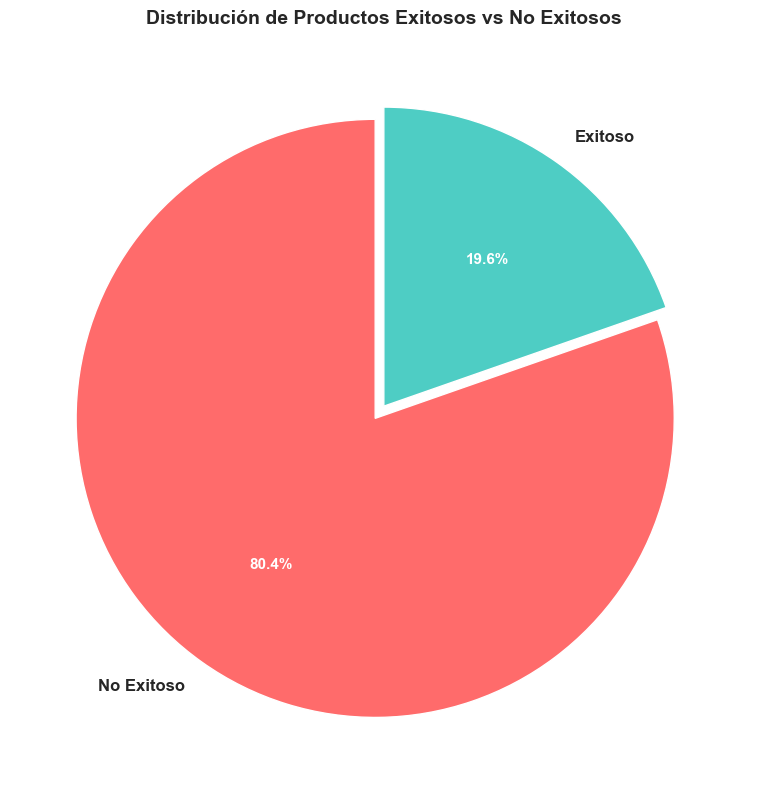

In [21]:
loves_p75 = df_products['loves_count'].quantile(0.75)
rating_threshold = 4.0

print(f"Criterios para producto exitoso:")
print(f"   - loves_count > {loves_p75:.0f} (percentil 75)")
print(f"   - rating >= {rating_threshold}")

df_products['is_successful'] = ((df_products['loves_count'] > loves_p75) & 
                                 (df_products['rating'] >= rating_threshold)).astype(int)

target_dist = df_products['is_successful'].value_counts()
print(f"\nDistribución de la Variable Target:")
print(f"   - No exitoso (0): {target_dist[0]} ({target_dist[0]/len(df_products)*100:.1f}%)")
print(f"   - Exitoso (1): {target_dist[1]} ({target_dist[1]/len(df_products)*100:.1f}%)")

plt.figure(figsize=(10, 8))
colors = ['#FF6B6B', '#4ECDC4']
wedges, texts, autotexts = plt.pie(target_dist.values, 
                                     labels=['No Exitoso', 'Exitoso'],
                                     autopct='%1.1f%%',
                                     startangle=90,
                                     colors=colors,
                                     explode=(0.05, 0))

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

plt.title('Distribución de Productos Exitosos vs No Exitosos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

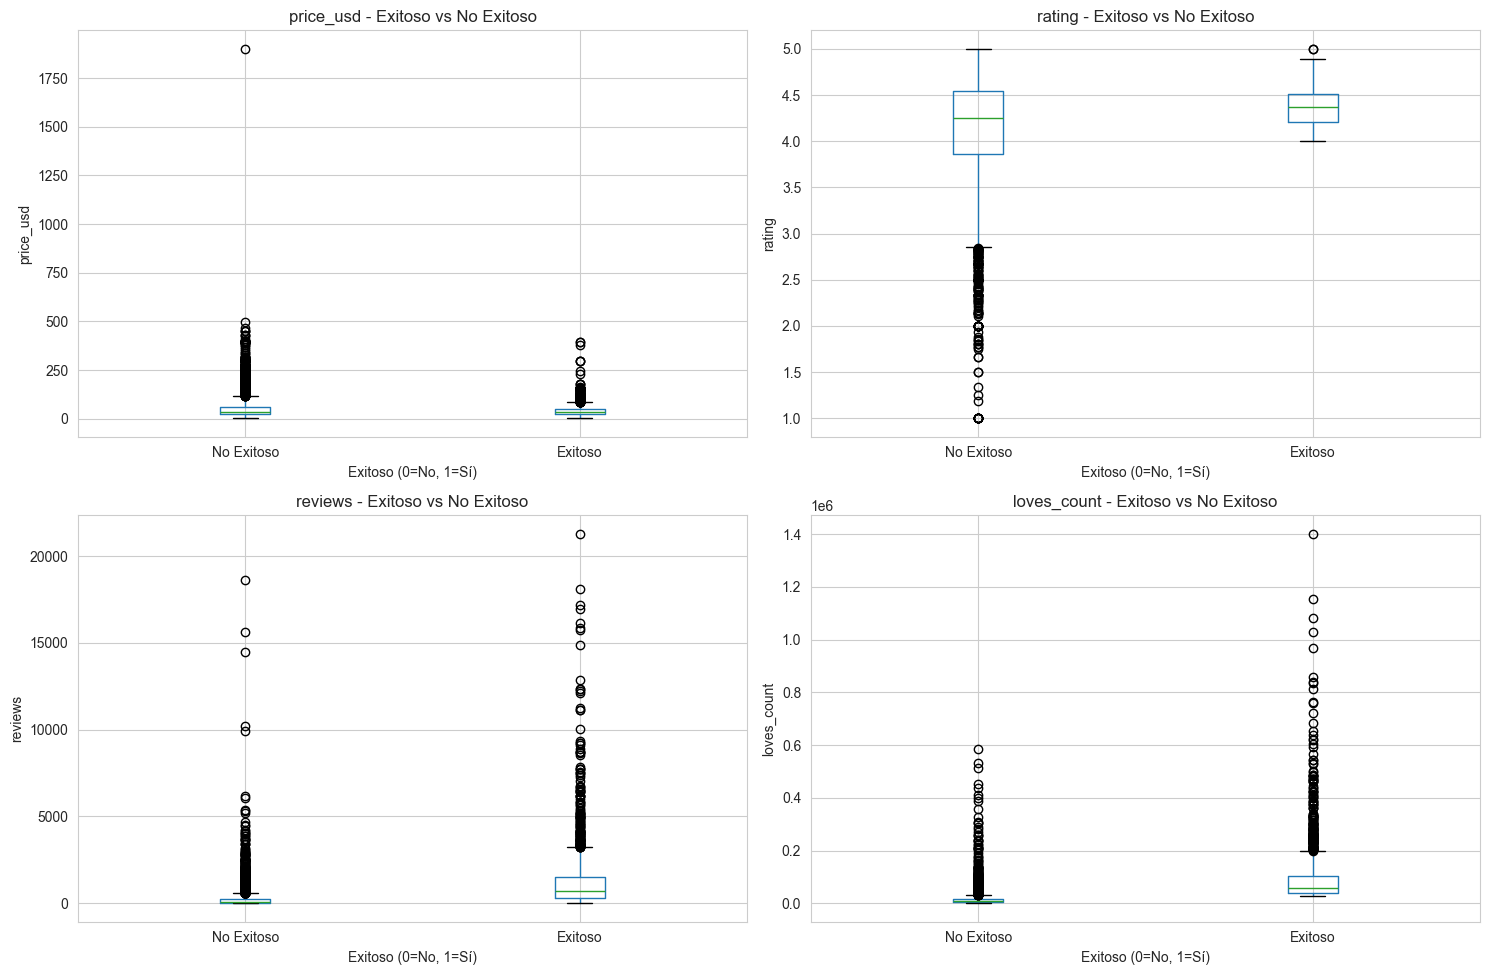

In [22]:
# Comparación de variables numéricas entre exitosos y no exitosos
comparison_cols = ['price_usd', 'rating', 'reviews', 'loves_count']
comparison_cols = [col for col in comparison_cols if col in df_products.columns]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(comparison_cols):
    df_products.boxplot(column=col, by='is_successful', ax=axes[idx])
    axes[idx].set_title(f'{col} - Exitoso vs No Exitoso')
    axes[idx].set_xlabel('Exitoso (0=No, 1=Sí)')
    axes[idx].set_ylabel(col)
    plt.sca(axes[idx])
    plt.xticks([1, 2], ['No Exitoso', 'Exitoso'])

plt.suptitle('')
plt.tight_layout()
plt.show()

## 9. Feature Importance Preliminar

Usaremos Random Forest para obtener una primera idea de las características más importantes

In [23]:
feature_cols = ['price_usd', 'rating', 'reviews', 'limited_edition', 'new', 
                'online_only', 'out_of_stock', 'sephora_exclusive', 'child_count']

feature_cols = [col for col in feature_cols if col in df_products.columns]

df_clean = df_products[feature_cols + ['is_successful']].dropna()

print(f"Dataset para feature importance:")
print(f"   - Registros: {len(df_clean)}")
print(f"   - Features: {len(feature_cols)}")
print(f"   - Features: {feature_cols}")

Dataset para feature importance:
   - Registros: 8216
   - Features: 9
   - Features: ['price_usd', 'rating', 'reviews', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'child_count']



FEATURE IMPORTANCE (Random Forest)

          Feature  Importance
          reviews       0.488
           rating       0.237
      child_count       0.133
        price_usd       0.076
      online_only       0.032
sephora_exclusive       0.014
              new       0.007
     out_of_stock       0.007
  limited_edition       0.005


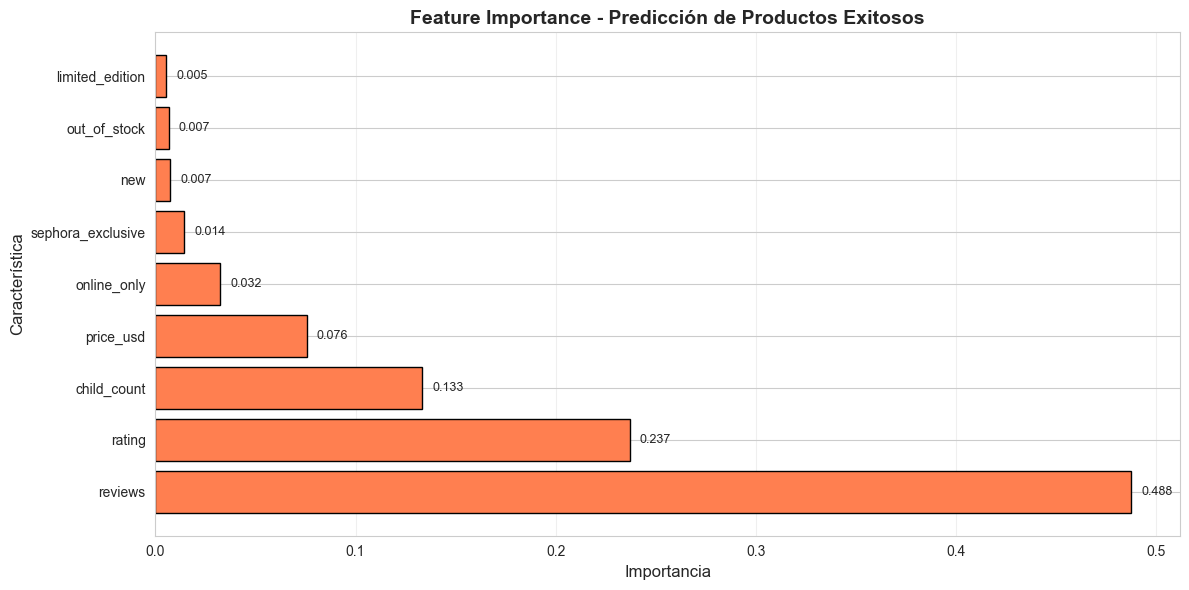

In [24]:
X = df_clean[feature_cols]
y = df_clean['is_successful']

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFEATURE IMPORTANCE (Random Forest)\n")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.barh(range(len(feature_importance)), feature_importance['Importance'], color='coral', edgecolor='black')
plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.title('Feature Importance - Predicción de Productos Exitosos', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, val in enumerate(feature_importance['Importance']):
    plt.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Resumen del Análisis Exploratorio

In [25]:
print("="*80)
print("RESUMEN DEL ANALISIS EXPLORATORIO")
print("="*80)

print(f"\nDATASET:")
print(f"   - Total de productos: {len(df_products):,}")
print(f"   - Total de reviews: {len(df_reviews):,}")
print(f"   - Productos exitosos: {df_products['is_successful'].sum():,} ({df_products['is_successful'].sum()/len(df_products)*100:.1f}%)")

print(f"\nCALIDAD DE DATOS:")
if len(nulls_products) > 0:
    print(f"   - Columnas con nulos (productos): {len(nulls_products)}")
    print(f"   - Columna con más nulos: {nulls_products.iloc[0]['Column']} ({nulls_products.iloc[0]['Null_Percentage']:.1f}%)")
else:
    print(f"   - Sin valores nulos en productos")

print(f"\nVARIABLES NUMERICAS:")
print(f"   - Total analizadas: {len(numeric_cols)}")
print(f"   - Variable con más outliers: {outlier_df.iloc[0]['Variable']} ({outlier_df.iloc[0]['Outlier_Pct']:.1f}%)")

print(f"\nVARIABLES CATEGORICAS:")
print(f"   - Total analizadas: {len(categorical_cols)}")
print(f"   - Marcas únicas: {df_products['brand_name'].nunique():,}")
if 'primary_category' in df_products.columns:
    print(f"   - Categorías primarias: {df_products['primary_category'].nunique()}")

print(f"\nFEATURE IMPORTANCE (Top 3):")
for idx, row in feature_importance.head(3).iterrows():
    print(f"   {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print(f"\nCONCLUSIONES PRELIMINARES:")
print(f"   - Dataset adecuado para modelado de clasificación")
print(f"   - Variable target balanceada (~{df_products['is_successful'].sum()/len(df_products)*100:.0f}% exitosos)")
print(f"   - Features clave identificadas: {', '.join(feature_importance.head(3)['Feature'].tolist())}")
print(f"   - Se requiere ingeniería de características para mejorar el modelo")

print("\n" + "="*80)

RESUMEN DEL ANALISIS EXPLORATORIO

DATASET:
   - Total de productos: 8,494
   - Total de reviews: 602,130
   - Productos exitosos: 1,669 (19.6%)

CALIDAD DE DATOS:
   - Columnas con nulos (productos): 14
   - Columna con más nulos: sale_price_usd (96.8%)

VARIABLES NUMERICAS:
   - Total analizadas: 9
   - Variable con más outliers: loves_count (11.2%)

VARIABLES CATEGORICAS:
   - Total analizadas: 9
   - Marcas únicas: 304
   - Categorías primarias: 9

FEATURE IMPORTANCE (Top 3):
   3. reviews: 0.4876
   2. rating: 0.2369
   9. child_count: 0.1334

CONCLUSIONES PRELIMINARES:
   - Dataset adecuado para modelado de clasificación
   - Variable target balanceada (~20% exitosos)
   - Features clave identificadas: reviews, rating, child_count
   - Se requiere ingeniería de características para mejorar el modelo



## 11. Guardar Dataset Procesado

In [26]:
os.makedirs('data', exist_ok=True)

df_products.to_csv('data/products_with_target.csv', index=False)
print("Dataset con variable target guardado en: data/products_with_target.csv")

summary_dict = {
    'total_products': len(df_products),
    'successful_products': int(df_products['is_successful'].sum()),
    'success_rate': float(df_products['is_successful'].sum()/len(df_products)),
    'top_features': feature_importance.head(5)['Feature'].tolist(),
    'feature_importance_scores': feature_importance.head(5)['Importance'].tolist()
}

import json
with open('data/eda_summary.json', 'w') as f:
    json.dump(summary_dict, f, indent=4)
    
print("Resumen de EDA guardado en: data/eda_summary.json")

Dataset con variable target guardado en: data/products_with_target.csv
Resumen de EDA guardado en: data/eda_summary.json


---

## Siguiente Paso

Con este análisis exploratorio completado, ahora procedo a:
1. Ingeniería de características (feature engineering)
2. Preprocesamiento de datos
3. Entrenamiento de modelos

Ejecuto todas las celdas de este notebook y comparto los resultados para continuar con el modelado.